In [26]:
import random
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List
import ast

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 1000)



In [ ]:
csv_paths = ['data/results/n_scaling_15_10/d18_m02_y2026_n10000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_15_10/d18_m02_y2026_n20000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_15_10/d18_m02_y2026_n30000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_15_10/d18_m02_y2026_n40000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_15_10/d18_m02_y2026_n50000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_15_10/d18_m02_y2026_n60000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_15_10/d18_m02_y2026_n70000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_15_10/d18_m02_y2026_n80000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_15_10/d18_m02_y2026_n90000_redSz7_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n10000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n20000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n30000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n40000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n50000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n60000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n70000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n80000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_10_5/d18_m02_y2026_n90000_redSz10_5_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n10000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n20000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n30000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n40000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n50000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n60000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n70000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n80000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_9_3/d18_m02_y2026_n90000_redSz9_3_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n10000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n20000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n30000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n40000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n50000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n60000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n70000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n80000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_5_2/d18_m02_y2026_n90000_redSz5_2_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n10000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n20000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n30000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n40000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n50000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n60000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n70000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n80000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_3_1/d18_m02_y2026_n90000_redSz3_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n10000_redSz1_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n20000_redSz1_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n30000_redSz1_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n40000_redSz1_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n50000_redSz1_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n60000_redSz1_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n70000_redSz1_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n80000_redSz1_1_sd1925134378/results_sd1925134378.csv', 'data/results/n_scaling_1_1/d18_m02_y2026_n90000_redSz1_1_sd1925134378/results_sd1925134378.csv']

In [ ]:
# def parse_reduce_tuple(val):
#     """Parse reduce_triggerSz_sizeLim column."""
#     try:
#         return ast.literal_eval(str(val))
#     except:
#         return None

# def load_all_csvs(csv_paths: List[str]) -> pd.DataFrame:
#     """Load and combine multiple experiment CSVs."""
#     dfs = []
#     for path in csv_paths:
#         df = pd.read_csv(path, index_col=0)
#         df['source_file'] = Path(path).parent.name 
#         dfs.append(df)
    
#     combined = pd.concat(dfs, ignore_index=True)

#     if 'reduce_triggerSz_sizeLim' in combined.columns:
#         parsed = combined['reduce_triggerSz_sizeLim'].apply(parse_reduce_tuple)
#         combined['trigger_sz'] = parsed.apply(lambda x: x[0] if x else None)
#         combined['size_lim']   = parsed.apply(lambda x: x[1] if x else None)
    
#     return combined

In [ ]:
df = load_all_csvs(csv_paths)


In [ ]:
def plot_n_scaling_comparison(df: pd.DataFrame):
    """
    Plot sumtest_time vs dataset_size for different reduction configs.
    Shows which configs scale better as n grows.
    """
    
    if 'dataset_size' not in df.columns or 'independent_variable' not in df.columns:
        print("  Skipping n-scaling plot: required columns not found")
        return
    
    n_scaling = df[df['independent_variable'] == 'dataset_size'].copy()
    if n_scaling.empty:
        print("  Skipping n-scaling plot: no dataset_size experiments found")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Left: Time vs n
    ax = axes[0]
    for config, group in n_scaling.groupby('reduce_triggerSz_sizeLim'):
        group = group.sort_values('dataset_size')
        
        x = group['dataset_size']
        y = group['sumtest_time_mean']
        yerr = group['sumtest_time_std'] # was using sum_time_std instead of sumtest_time_std
        
        # Format label nicely
        try:
            trigger, size_lim = ast.literal_eval(str(config))
            label = f"({trigger},{size_lim})" if trigger < 1e6 else "no reduction"
        except:
            label = str(config)
        
        ax.errorbar(x, y, yerr=yerr, marker='o', linewidth=2, markersize=5, capsize=3, alpha=0.8, label=label)
    
    ax.set_xlabel('Dataset Size (n)', fontsize=12)
    ax.set_ylabel('Mean SUMTEST Time (ms)', fontsize=12)
    ax.set_title('Speed vs Dataset Size by Reduction Config\n(lower = better)', fontsize=13)
    ax.legend(fontsize=9, title='(trigger, size_lim)')
    ax.grid(True, alpha=0.3)
    
    # Right: Coverage vs n
    ax = axes[1]
    if 'result_coverage' in n_scaling.columns:
        for config, group in n_scaling.groupby('reduce_triggerSz_sizeLim'):            
            group = group.sort_values('dataset_size')
            
            x = group['dataset_size']
            y = group['result_coverage']
        
            # Format label nicely
            try:
                trigger, size_lim = ast.literal_eval(str(config))
                label = f"({trigger},{size_lim})" if trigger < 1e6 else "no reduction"
            except:
                label = str(config)
            
            ax.plot(group['dataset_size'], group['result_coverage'],marker='o', linewidth=2, markersize=5, alpha=0.8, label=label)
        
        ax.set_xlabel('Dataset Size (n)', fontsize=12)
        ax.set_ylabel('Mean Result Coverage', fontsize=12)
        ax.set_title('Coverage vs Dataset Size\n(shows overapproximation)', fontsize=13)
        ax.legend(fontsize=9, title='(trigger, size_lim)')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'result_coverage\nnot available',
               ha='center', va='center', fontsize=14, color='gray')
        ax.axis('off')
    
    fig.suptitle('N-Scaling Comparison Across Reduction Configs', fontsize=14, y=1.02)
    fig.tight_layout()
    path = './alex/' + 'trials_n_scaling_redVary.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.plot()
    # plt.close(fig)
    # print(f"  Saved: {path}")

In [ ]:
n1mil_scaling_7_2_csv_paths = ['data/results/n1mil_scaling_7_2/d19_m02_y2026_n_10000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_60000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_110000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_160000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_210000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_260000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_310000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_360000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_410000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_460000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_510000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_560000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_610000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_660000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_710000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_760000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_810000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_860000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_910000_7_2_sd1979149363/results_sd1979149363.csv', 'data/results/n1mil_scaling_7_2/d19_m02_y2026_n_960000_7_2_sd1979149363/results_sd1979149363.csv']
df_n1mil_scaling_7_2 = load_all_csvs(n1mil_scaling_7_2_csv_paths)
plot_n_scaling_comparison(df_n1mil_scaling_7_2)

In [ ]:
trials_n_scaling_redVary_csv_paths = ['data/results/n_scaling_15_10/d19_m02_y2026_n10000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n20000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n30000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n40000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n50000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n60000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n70000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n80000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n90000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_15_10/d19_m02_y2026_n100000_redSz15_10_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n10000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n20000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n30000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n40000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n50000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n60000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n70000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n80000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n90000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_10_5/d19_m02_y2026_n100000_redSz10_5_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n10000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n20000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n30000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n40000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n50000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n60000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n70000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n80000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n90000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_4_2/d19_m02_y2026_n100000_redSz4_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n10000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n20000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n30000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n40000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n50000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n60000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n70000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n80000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n90000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_9_3/d19_m02_y2026_n100000_redSz9_3_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n10000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n20000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n30000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n40000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n50000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n60000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n70000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n80000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n90000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_5_2/d19_m02_y2026_n100000_redSz5_2_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n10000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n20000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n30000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n40000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n50000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n60000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n70000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n80000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n90000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_3_1/d19_m02_y2026_n100000_redSz3_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n10000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n20000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n30000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n40000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n50000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n60000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n70000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n80000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n90000_redSz1_1_sd1980791682/results_sd1980791682.csv', 'data/results/n_scaling_1_1/d19_m02_y2026_n100000_redSz1_1_sd1980791682/results_sd1980791682.csv']
df_trials_n_scaling_redVary = load_all_csvs(trials_n_scaling_redVary_csv_paths)
plot_n_scaling_comparison(df_trials_n_scaling_redVary)

In [ ]:
reduction_sweep_n100k_csv_paths = ['data/results/reduction_sweep/d19_m02_y2026_red_15_10_sd1988665848/results_sd1988665848.csv', 'data/results/reduction_sweep/d19_m02_y2026_red_10_5_sd1988665848/results_sd1988665848.csv', 'data/results/reduction_sweep/d19_m02_y2026_red_9_3_sd1988665848/results_sd1988665848.csv', 'data/results/reduction_sweep/d19_m02_y2026_red_7_2_sd1988665848/results_sd1988665848.csv', 'data/results/reduction_sweep/d19_m02_y2026_red_5_2_sd1988665848/results_sd1988665848.csv', 'data/results/reduction_sweep/d19_m02_y2026_red_3_1_sd1988665848/results_sd1988665848.csv', 'data/results/reduction_sweep/d19_m02_y2026_red_1_1_sd1988665848/results_sd1988665848.csv']
df_reduction_sweep_n100k = load_all_csvs(reduction_sweep_n100k_csv_paths)
plot_n_scaling_comparison(df_reduction_sweep_n100k)

In [ ]:
# df_reduction_sweep_n100k
plot_size_vs_time(df_reduction_sweep_n100k, 'reduce_triggerSz_sizeLim')

In [ ]:
def plot_size_vs_time(df: pd.DataFrame, iv: str):
    """
    Plot sumtest_time vs dataset_size for different reduction configs.
    Shows which configs scale better as n grows.
    """
    if iv not in df.columns or 'independent_variable' not in df.columns:
        print(f"  Skipping plot: no {iv} experiments found")
        return
    
    data = df[df['independent_variable'] == iv].copy()

    if data.empty:
        print(f"  Skipping plot: no {iv} experiments found")
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Left: Time vs Cover
    ax = axes[0]
    for config, group in data.groupby('reduce_triggerSz_sizeLim'):
        group = group.sort_values(iv)
        
        x = group['sumtest_time_mean']
        y = group['result_coverage_mean']
        # yerr = group['sumtest_time_std'] # was using sum_time_std instead of sumtest_time_std
        yerr = None


        # Format label nicely
        try:
            trigger, size_lim = ast.literal_eval(str(config))
            label = f"({trigger},{size_lim})" if trigger < 1e6 else "no reduction"
        except:
            label = str(config)
        
        # ax.errorbar(x, y, yerr=yerr, marker='o', linewidth=2, markersize=5, capsize=3, alpha=0.8, label=label)
        ax.scatter(x, y, s=60, alpha=0.8, label=label)
        axes[1].errorbar(x, y, yerr=yerr, marker='o', linewidth=2, markersize=5, capsize=3, alpha=0.8, label=label)
    
    ax.set_xlabel('sumtest_time_mean (ms)', fontsize=12)
    ax.set_ylabel('result_coverage_mean (volume)', fontsize=12)
    ax.set_title('Speed vs Dataset Size by Reduction Config\n(lower = better)', fontsize=13)
    ax.legend(fontsize=9, title='(trigger, size_lim)')
    ax.grid(True, alpha=0.3)
    
    # # Right: Coverage vs n
    # ax = axes[1]
    # if 'result_coverage' in data.columns:
    #     for config, group in data.groupby('reduce_triggerSz_sizeLim'):            
    #         group = group.sort_values('dataset_size')
            
    #         x = group['dataset_size']
    #         y = group['result_coverage']
        
    #         # Format label nicely
    #         try:
    #             trigger, size_lim = ast.literal_eval(str(config))
    #             label = f"({trigger},{size_lim})" if trigger < 1e6 else "no reduction"
    #         except:
    #             label = str(config)
            
    #         ax.plot(group['dataset_size'], group['result_coverage'],marker='o', linewidth=2, markersize=5, alpha=0.8, label=label)
        
    #     ax.set_xlabel('Dataset Size (n)', fontsize=12)
    #     ax.set_ylabel('Mean Result Coverage', fontsize=12)
    #     ax.set_title('Coverage vs Dataset Size\n(shows overapproximation)', fontsize=13)
    #     ax.legend(fontsize=9, title='(trigger, size_lim)')
    #     ax.grid(True, alpha=0.3)
    # else:
    #     ax.text(0.5, 0.5, 'result_coverage\nnot available',
    #            ha='center', va='center', fontsize=14, color='gray')
    #     ax.axis('off')
    
    # fig.suptitle('N-Scaling Comparison Across Reduction Configs', fontsize=14, y=1.02)
    # fig.tight_layout()
    path = './graphics/' + 'timeVScoverage_varyRED.png'
    fig.savefig(path, dpi=150, bbox_inches='tight')
    plt.plot()
    # plt.close(fig)
    # print(f"  Saved: {path}")

In [ ]:
def pareto_frontier(df, x=None, y=None, maximize_x=False, maximize_y=False):
    x = df['sumtest_time_mean']
    y = df['result_coverage_mean']
    # x = time, y = size/inflation
    # minimize both by default
    points = np.array(list(zip(x, y)))
    print(points)
    
    frontier = []
    for p in points:
        dominated = False
        for q in points:
            if (q[0] <= p[0] and q[1] <= p[1]) and (q[0] < p[0] or q[1] < p[1]):
                dominated = True
                break
        if not dominated:
            frontier.append(p)
    return np.array(frontier)


In [ ]:
frontier = pareto_frontier(df_reduction_sweep_n100k)

In [27]:
def load_all_csvs(csv_paths: List[str]) -> pd.DataFrame:
    """Load and combine multiple experiment CSVs."""
    dfs = []
    for path in csv_paths:
        df = pd.read_csv(path, index_col=0)
        df['source_file'] = Path(path).parent.name  # track which experiment it came from
        dfs.append(df)
    
    combined = pd.concat(dfs, ignore_index=True)
    
    # add in tuple representation vs string for convenience
    combined['gap_size_range_tuple'] = combined['gap_size_range'].apply(ast.literal_eval)
    combined['reduce_triggerSz_sizeLim_tuple'] = combined['reduce_triggerSz_sizeLim'].apply(ast.literal_eval)
    return combined

In [61]:
csv_paths = ['data/results/2858060082/ni_sweeping10k/ni15_red500_10_sweep//results_sd2858060082.csv', 'data/results/2858060082/ni_sweeping10k/ni15_red500_5_sweep//results_sd2858060082.csv', 'data/results/2858060082/ni_sweeping10k/ni15_red300_10_sweep//results_sd2858060082.csv', 'data/results/2858060082/ni_sweeping10k/ni15_red300_5_sweep//results_sd2858060082.csv', 'data/results/2858060082/ni_sweeping10k/ni15_red150_10_sweep//results_sd2858060082.csv', 'data/results/2858060082/ni_sweeping10k/ni15_red150_5_sweep//results_sd2858060082.csv', 'data/results/2858060082/ni_sweeping10k/ni15_red15_10_sweep//results_sd2858060082.csv', 'data/results/2858060082/ni_sweeping10k/ni15_red10_5_sweep//results_sd2858060082.csv', 'data/results/2858060082/ni_sweeping10k/ni15_red3_2_sweep//results_sd2858060082.csv', 'data/results/2858060082/ni_sweeping10k/ni15_red1_1_sweep//results_sd2858060082.csv']
df = load_all_csvs(csv_paths)
df

,master_seed,data_type,num_trials,dataset_size,uncertain_ratio,interval_size_range,mult_size_range,num_intervals,gap_size,interval_width,num_intervals_range,gap_size_range,interval_width_range,reduce_triggerSz_sizeLim,independent_variable,min_time_mean,min_time_std,max_time_mean,max_time_std,sum_time_mean,sum_time_std,sumtest_time_mean,sumtest_time_std,reduce_calls_mean,max_interval_count_mean,total_interval_count_mean,combine_calls_mean,result_size_mean,result_coverage_mean,source_file,gap_size_range_tuple,reduce_triggerSz_sizeLim_tuple
0,2858060082,set,5,2000,0.0,"(1, 100000)","(1, 5)",1,NaN,NaN,NaN,"(10000, 15000)","(100, 600)","(500, 10)",num_intervals,1.8644,0.068759,1.8428,0.081239,1.4074,0.087299,1.3444,0.051852,0.0,1.0,2000.0,2000.0,1.0,703051.4,ni15_red500_10_sweep,"(10000, 15000)","(500, 10)"
1,2858060082,set,5,2000,0.0,"(1, 100000)","(1, 5)",2,NaN,NaN,NaN,"(10000, 15000)","(100, 600)","(500, 10)",num_intervals,2.2948,0.018016,2.4826,0.066473,10.7266,0.127066,10.5002,0.215023,222.2,793.6,228522.8,2000.0,1.0,26393640.4,ni15_red500_10_sweep,"(10000, 15000)","(500, 10)"
2,2858060082,set,5,2000,0.0,"(1, 100000)","(1, 5)",3,NaN,NaN,NaN,"(10000, 15000)","(100, 600)","(500, 10)",num_intervals,2.5660,0.042071,2.8802,0.026918,21.4058,0.091059,20.3902,0.366145,334.0,1360.8,367132.2,2000.0,1.0,52112453.8,ni15_red500_10_sweep,"(10000, 15000)","(500, 10)"
3,2858060082,set,5,2000,0.0,"(1, 100000)","(1, 5)",4,NaN,NaN,NaN,"(10000, 15000)","(100, 600)","(500, 10)",num_intervals,2.9474,0.069408,3.5770,0.141345,35.6566,0.321474,34.8140,0.831101,401.0,1638.4,546378.4,2000.0,1.0,77758009.6,ni15_red500_10_sweep,"(10000, 15000)","(500, 10)"
4,2858060082,set,5,2000,0.0,"(1, 100000)","(1, 5)",5,NaN,NaN,NaN,"(10000, 15000)","(100, 600)","(500, 10)",num_intervals,3.3354,0.141184,4.0472,0.123047,26.1738,0.269680,24.7126,0.214464,501.0,1875.0,395757.0,2000.0,1.0,103447723.8,ni15_red500_10_sweep,"(10000, 15000)","(500, 10)"
5,2858060082,set,5,2000,0.0,"(1, 100000)","(1, 5)",6,NaN,NaN,NaN,"(10000, 15000)","(100, 600)","(500, 10)",num_intervals,3.6700,0.176718,4.5200,0.043299,56.9910,1.705595,53.3272,0.439772,502.0,2246.4,778509.6,2000.0,1.0,129174587.4,ni15_red500_10_sweep,"(10000, 15000)","(500, 10)"
6,2858060082,set,5,2000,0.0,"(1, 100000)","(1, 5)",7,NaN,NaN,NaN,"(10000, 15000)","(100, 600)","(500, 10)",num_intervals,4.0036,0.200750,5.2338,0.072689,106.4818,1.916123,104.2414,2.169146,502.0,3430.0,1397979.8,2000.0,1.0,154830867.0,ni15_red500_10_sweep,"(10000, 15000)","(500, 10)"
7,2858060082,set,5,2000,0.0,"(1, 100000)","(1, 5)",8,NaN,NaN,NaN,"(10000, 15000)","(100, 600)","(500, 10)",num_intervals,4.3850,0.143113,5.9514,0.167977,32.3934,0.444945,31.8692,2.391272,665.0,3584.0,426025.6,2000.0,1.0,180474438.4,ni15_red500_10_sweep,"(10000, 15000)","(500, 10)"
8,2858060082,set,5,2000,0.0,"(1, 100000)","(1, 5)",9,NaN,NaN,NaN,"(10000, 15000)","(100, 600)","(500, 10)",num_intervals,4.4532,0.410564,9.1486,5.226271,33.3578,0.356330,37.1214,9.467586,665.8,3913.6,456932.8,2000.0,1.0,186718890.6,ni15_red500_10_sweep,"(10000, 15000)","(500, 10)"
9,2858060082,set,5,2000,0.0,"(1, 100000)","(1, 5)",10,NaN,NaN,NaN,"(10000, 15000)","(100, 600)","(500, 10)",num_intervals,4.3258,0.105163,6.1834,0.333724,33.5234,0.148033,30.9684,0.531709,666.4,3824.0,451110.4,2000.0,1.0,186641953.0,ni15_red500_10_sweep,"(10000, 15000)","(500, 10)"


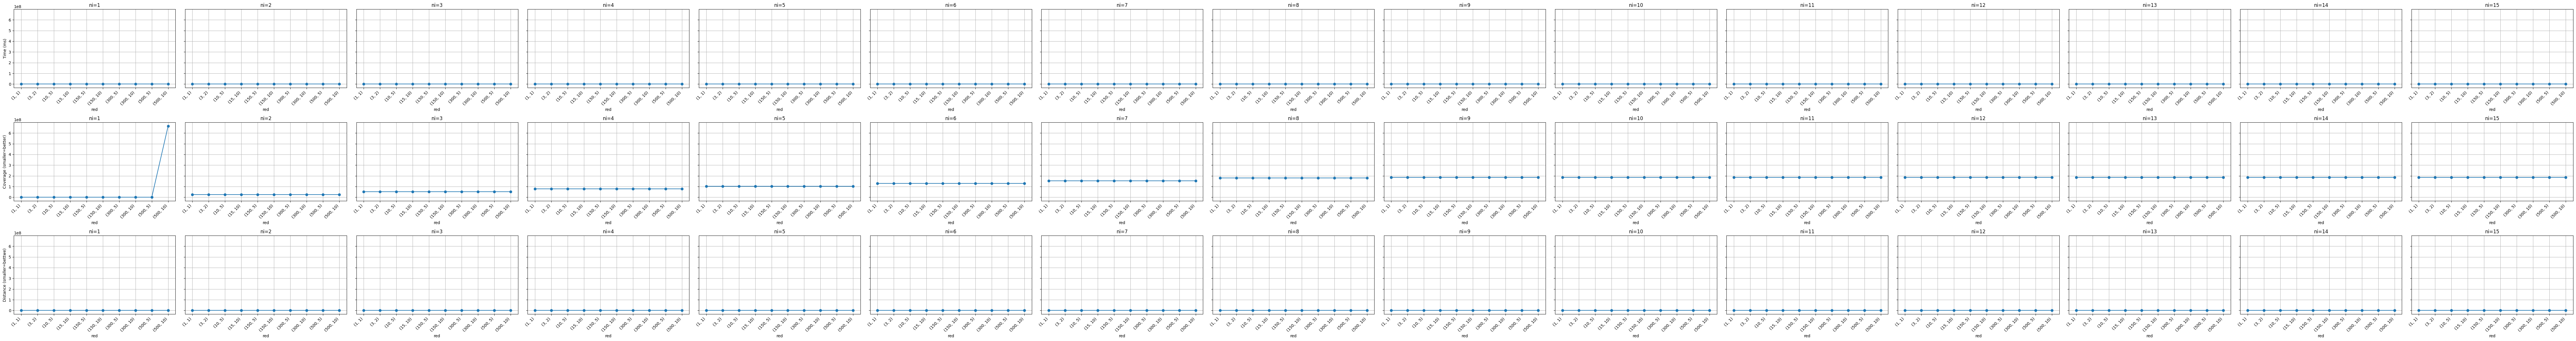

In [62]:
def safe_normalize(series):
        r = series.max() - series.min()
        return (series - series.min()) / r if r > 0 else pd.Series(0.0, index=series.index)

# gap_params = sorted(df['gap_size'].unique())
n = len(df['num_intervals'].unique())
reduce_params = sorted(df['reduce_triggerSz_sizeLim_tuple'].unique())
x_labels = [str(r) for r in reduce_params]


fig, axes=  plt.subplots(3, n, figsize=(6*n,12), sharey=True)
for i, ni in enumerate(sorted(df['num_intervals'].unique())):
    df_ni = df[df['num_intervals'] == ni].copy()

    # PLot 1: time
    ax = axes[0, i]
    y = df_ni['sum_time_mean']
    ax.plot(x_labels, y, marker='o')
    ax.set_title(f'ni={ni}')
    ax.set_xlabel('red')
    ax.xaxis.set_ticks(x_labels)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.grid(True)

    # Plot 2: coverage
    ax = axes[1, i]
    y = df_ni['result_coverage_mean']
    ax.plot(x_labels, y, marker='o')
    ax.set_title(f'ni={ni}')
    ax.set_xlabel('red')
    ax.xaxis.set_ticks(x_labels)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.grid(True)

    # Plot 3: distance of both time and coverage
    # normalize time and coverage to equal weight (x-min)/(max-min)
    df_ni['time_norm'] = safe_normalize(df_ni['sum_time_mean'])
    df_ni['cov_norm'] = safe_normalize(df_ni['result_coverage_mean'])
    scores = (df_ni['time_norm']**2 + df_ni['cov_norm']**2)**0.5

    ax = axes[2, i]
    ax.plot(x_labels, scores, marker='o')
    ax.set_title(f'ni={ni}')
    ax.set_xlabel('red')
    ax.xaxis.set_ticks(x_labels)
    ax.set_xticklabels(x_labels, rotation=45, ha='right')
    ax.grid(True)

axes[0][0].set_ylabel('Time (ms)')
axes[1][0].set_ylabel('Coverage (smaller=better)')
axes[2][0].set_ylabel('Distance (smaller=bettwe)')
plt.tight_layout()
# plt.savefig('./graphics/gapSweepN10k.jpg')
plt.show()

In [90]:
REDUCE_PARAM_NAME = 'reduce_triggerSz_sizeLim'
def plot_time_coverage_by_reduce(df: pd.DataFrame, indep_variable: str) -> str:
    ''' plot time vs IV and coverage vs IV for'''
    # Sort dataframe by dataset size
    df_sorted = df.sort_values(indep_variable)

    # Group by reduction parameters
    dfg = df_sorted.groupby(REDUCE_PARAM_NAME)

    # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    param_str = (
            f'iv={sorted(df["independent_variable"].unique())} | '
            f'n={sorted(df["dataset_size"].unique())} | '
            f'gaps={sorted(df["gap_size_range"].unique())} | '
            f'widths={sorted(df["interval_width_range"].unique())}'
            f'uncert={sorted(df["uncertain_ratio"].unique())}'
            f'dataPath={self.resultFilepath}'
            f'seed={self.master_seed}'
    )
    fig.text(0.5, -0.02, param_str, ha='center', fontsize=7, color='black')
    # fig.text()
    
    for p, group in dfg:
        # Make sure each group is sorted by dataset_size
        group = group.sort_values(indep_variable)
        x = group[indep_variable]
        y_time = group['sum_time_mean']
        y_time_err = group['sum_time_std']
        y_coverage = group['result_coverage_mean']

        # Plot time with error bars
        ax1.errorbar(x, y_time, yerr=y_time_err, fmt='o-', capsize=5, label=str(p))
        # Plot coverage
        ax2.errorbar(x, y_coverage, fmt='o-', capsize=5, label=str(p))

    # TIME axis labels
    ax1.set_ylabel('Time (ms)')
    ax1.set_xlabel(indep_variable)    
    ax1.set_title(f'Time vs {indep_variable} by Reduction Parameters')
    ax1.grid(True, alpha=0.3)
    ax1.legend(title='Reduce Params')

    # COVERAGE axis labels
    ax2.set_ylabel('Coverage')
    ax2.set_xlabel(indep_variable)
    ax2.set_title(f'Coverage vs {indep_variable} by Reduction Parameters')
    ax2.grid(True, alpha=0.3)
    ax2.legend(title='Reduce Params')
    
    plt.tight_layout()
    # outfile = f'time_accuracy_sd{self.master_seed}'
    # outpath = f"{self.resultFilepath}/{outfile}"
    # plt.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.show()
    # return outpath

In [91]:
plot_time_coverage_by_reduce(df, 'num_intervals')

NameError: name 'self' is not defined